# 05_1. Python-Only Workflow

This companion notebook replaces the mixed-engine workflow with a pure Python session workflow. The goal is to show
what can already be done interactively with the native snapshot model and the Python LGM adapter alone.

**Purpose**
- run the Python LGM adapter on a programmatic snapshot
- show how market and portfolio updates flow through one session
- keep the workflow focused on reusable Python objects rather than external runs

**What you will learn**
- how to launch a Python-only XVA session
- how to compare base, market-bumped, and portfolio-updated runs
- which pieces of the workflow are already interactive without any external engine


In [1]:
from pathlib import Path
import os
import sys

def _pythonorerunner_root(candidate: Path) -> bool:
    return (
        (candidate / "notebook_series" / "series_helpers.py").exists()
        and (candidate / "py_ore_tools").exists()
    )

def _engine_root(candidate: Path) -> bool:
    return (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists()

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if _pythonorerunner_root(candidate) or _engine_root(candidate):
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if _engine_root(repo_hint):
        return repo_hint
    standalone_hint = Path("/Users/gordonlee/Documents/PythonOreRunner")
    if _pythonorerunner_root(standalone_hint):
        return standalone_hint
    raise RuntimeError("Could not locate the Engine repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "notebook_series" if _pythonorerunner_root(REPO_ROOT) else REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)


/Users/gordonlee/Documents/PythonOreRunner


In [2]:
from dataclasses import replace

from native_xva_interface import FXForward, PythonLgmAdapter, Trade, XVAEngine

snapshot = nh.make_programmatic_snapshot(num_paths=768)
adapter = PythonLgmAdapter(fallback_to_swig=False)
session = XVAEngine(adapter=adapter).create_session(snapshot)

base_result = session.run(return_cubes=False)
display(nh.snapshot_overview(snapshot))
display(nh.trade_frame(snapshot))
display(nh.quote_family_frame(snapshot))
display(nh.result_metrics_frame(base_result))


,component,count,notes
0,market quotes,4,2026-03-08
1,fixings,2,dataclass
2,trades,2,dataclass
3,netting sets,1,EUR
4,collateral balances,1,2026-03-08
5,analytics,4,"CVA,DVA,FVA,MVA"


,trade_id,trade_type,counterparty,netting_set,product_type,currency_or_pair,notional,maturity_years
0,IRS_DEMO_1,Swap,CP_A,NS_EUR,IRS,EUR,5000000,5.0
1,FXFWD_DEMO_1,FxForward,CP_A,NS_EUR,FXForward,EURUSD,2000000,1.0


,family,count
0,FX,1
1,IR_SWAP,1
2,ZERO,2


,metric,value
0,PV,-17807.802732
1,CVA,3483.783671
2,DVA,4154.326721
3,FBA,2136.375502
4,FCA,3058.123005
5,FVA,5194.498507
6,MVA,-50.267659
7,XVA_TOTAL,17976.839747


## Base run

The base snapshot is intentionally small. That keeps the session updates easy to reason about and makes it obvious
which change caused which metric move.


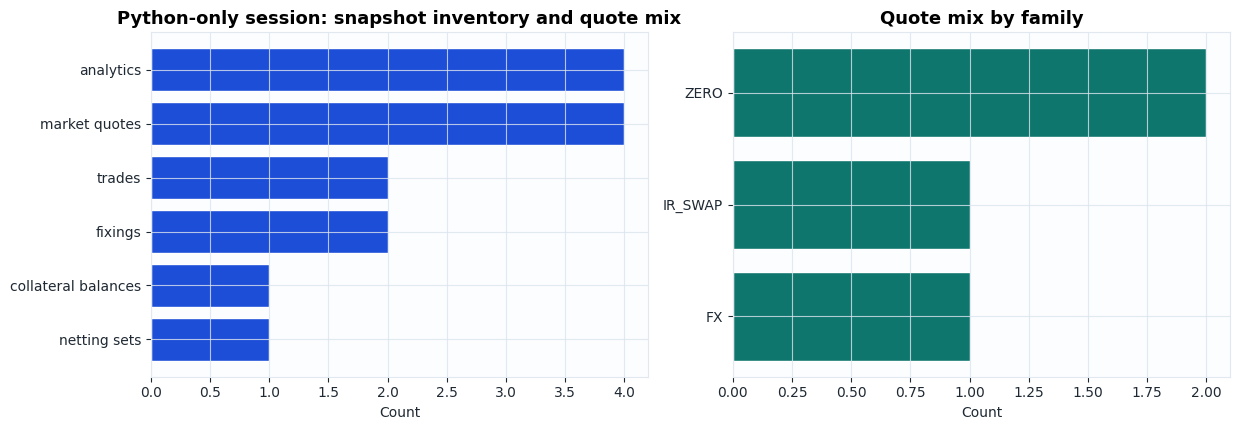

In [3]:
nh.plot_snapshot_composition(snapshot, title="Python-only session: snapshot inventory and quote mix")


## Market update

First change a small set of market quotes and rerun the same session. This isolates the market sensitivity of the
current portfolio without rebuilding a new notebook state from scratch.


,metric,base,market_bump,delta,abs_delta
0,CVA,3483.783671,3647.548654,163.764983,163.764983
1,DVA,4154.326721,3999.294559,-155.032162,155.032162
2,FBA,2136.375502,2057.884265,-78.491237,78.491237
3,FCA,3058.123005,3198.265383,140.142378,140.142378
4,FVA,5194.498507,5256.149648,61.651141,61.651141
5,MVA,-50.267659,-48.420806,1.846853,1.846853
6,PV,-17807.802732,9511.113714,27318.916446,27318.916446
7,XVA_TOTAL,17976.839747,18110.721702,133.881956,133.881956


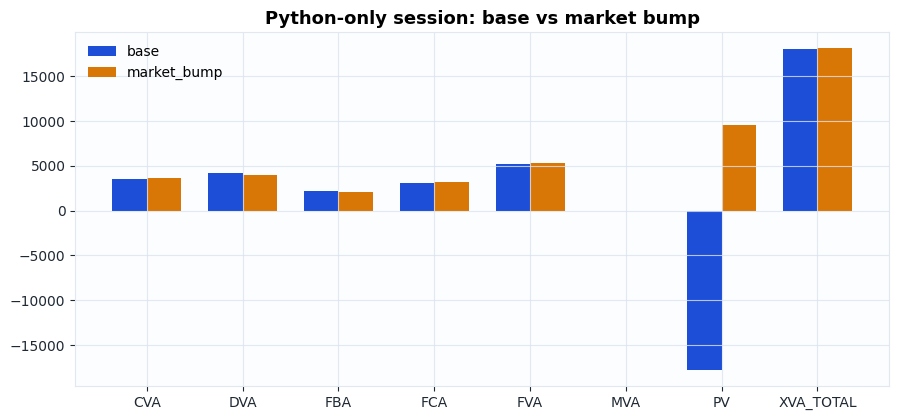

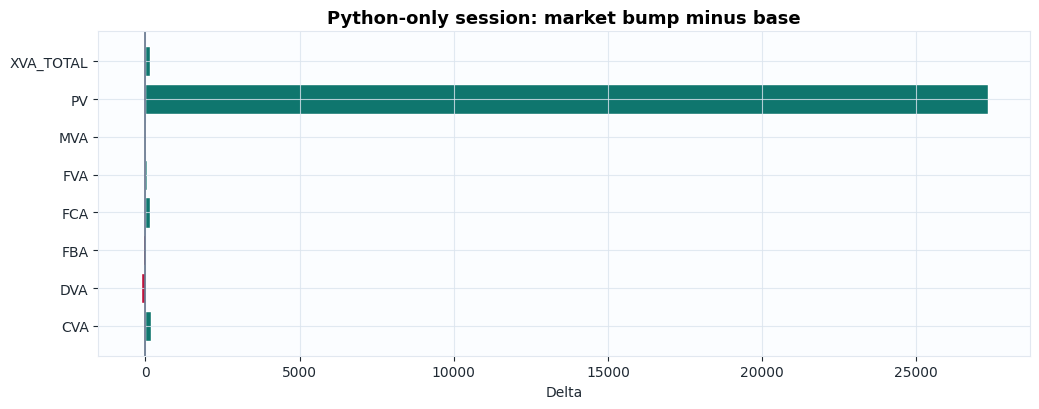

In [4]:
bumped_quotes = []
for quote in snapshot.market.raw_quotes:
    if quote.key == "ZERO/RATE/EUR/1Y":
        bumped_quotes.append(replace(quote, value=quote.value + 0.0010))
    elif quote.key == "FX/EUR/USD":
        bumped_quotes.append(replace(quote, value=quote.value + 0.0150))
    else:
        bumped_quotes.append(quote)
bumped_market = replace(snapshot.market, raw_quotes=tuple(bumped_quotes))
session.update_market(bumped_market)
market_result = session.run(return_cubes=False)

market_compare = nh.compare_results_frame("base", base_result, "market_bump", market_result)
display(market_compare)
nh.plot_metric_comparison(market_compare, "base", "market_bump", title="Python-only session: base vs market bump")
nh.plot_metric_delta(market_compare, title="Python-only session: market bump minus base")


The delta view is more informative than the level view once the baseline is familiar. It shows which metrics are
genuinely moving and which are mostly stable to this small bump.


## Portfolio update

Next add one trade and reprice through the same Python session. This is the workflow analogue of a trader-side
portfolio patch rather than a market move.


,metric,base,portfolio_patch,delta,abs_delta
0,CVA,3483.783671,4800.646319,1316.862648,1316.862648
1,DVA,4154.326721,5674.663268,1520.336547,1520.336547
2,FBA,2136.375502,2907.906517,771.531015,771.531015
3,FCA,3058.123005,4196.659241,1138.536236,1138.536236
4,FVA,5194.498507,7104.565758,1910.067251,1910.067251
5,MVA,-50.267659,-68.421330,-18.153671,18.153671
6,PV,-17807.802732,-21438.885914,-3631.083182,3631.083182
7,XVA_TOTAL,17976.839747,24616.019773,6639.180026,6639.180026


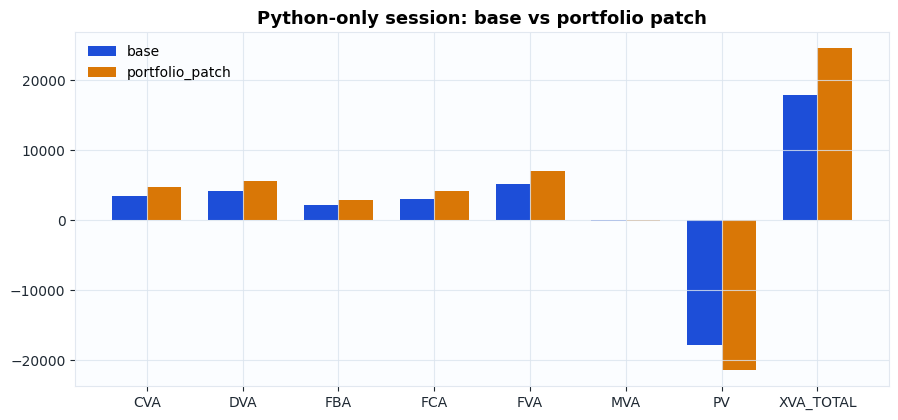

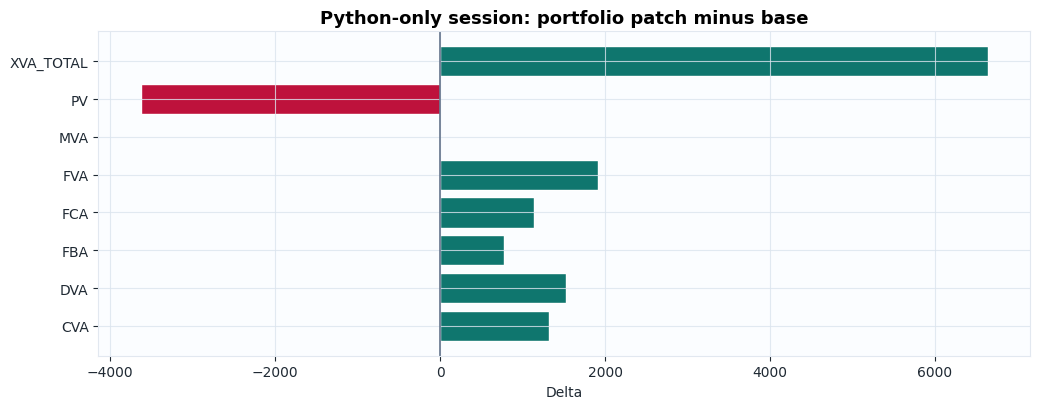

In [5]:
session.update_market(snapshot.market)
session.update_portfolio(
    add=[
        Trade(
            trade_id="FXFWD_PATCH_2",
            counterparty="CP_A",
            netting_set="NS_EUR",
            trade_type="FxForward",
            product=FXForward(
                pair="EURUSD",
                notional=1_500_000,
                strike=1.12,
                maturity_years=1.5,
                buy_base=False,
            ),
        )
    ]
)
portfolio_result = session.run(return_cubes=False)

portfolio_compare = nh.compare_results_frame("base", base_result, "portfolio_patch", portfolio_result)
display(portfolio_compare)
nh.plot_metric_comparison(portfolio_compare, "base", "portfolio_patch", title="Python-only session: base vs portfolio patch")
nh.plot_metric_delta(portfolio_compare, title="Python-only session: portfolio patch minus base")


,run,pv,xva_total
0,base,-17807.802732,17976.839747
1,market_bump,9511.113714,18110.721702
2,portfolio_patch,-21438.885914,24616.019773


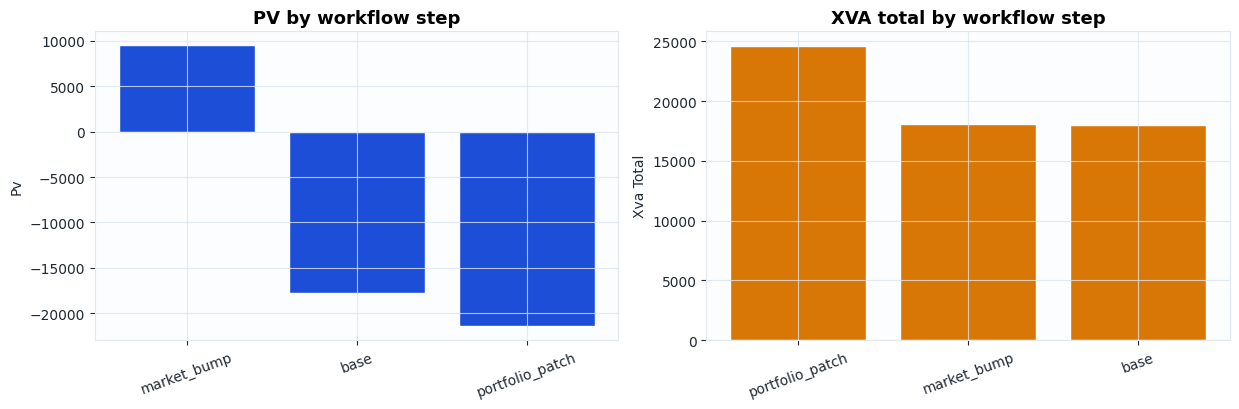

In [6]:
workflow_summary = pd.DataFrame(
    [
        {"run": "base", "pv": base_result.pv_total, "xva_total": base_result.xva_total},
        {"run": "market_bump", "pv": market_result.pv_total, "xva_total": market_result.xva_total},
        {"run": "portfolio_patch", "pv": portfolio_result.pv_total, "xva_total": portfolio_result.xva_total},
    ]
)
display(workflow_summary)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_bar_frame(workflow_summary, "run", "pv", title="PV by workflow step", color=nh.PALETTE["blue"], ax=axes[0])
nh.plot_bar_frame(workflow_summary, "run", "xva_total", title="XVA total by workflow step", color=nh.PALETTE["gold"], ax=axes[1])
plt.tight_layout()
plt.show()
plt.close(fig)


## Capabilities in this workflow

The capability table is still useful here, but it is read purely as a Python-side checklist rather than a split
between engines.


,capability,python_only
0,Programmatic snapshot build,True
1,Session market updates,True
2,Session portfolio updates,True
3,Pathwise exposure and XVA metrics,True
4,Fresh external run required,False


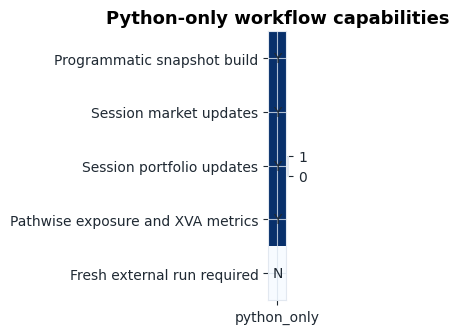

In [7]:
capability_df = pd.DataFrame(
    [
        {"capability": "Programmatic snapshot build", "python_only": True},
        {"capability": "Session market updates", "python_only": True},
        {"capability": "Session portfolio updates", "python_only": True},
        {"capability": "Pathwise exposure and XVA metrics", "python_only": True},
        {"capability": "Fresh external run required", "python_only": False},
    ]
)
display(capability_df)
nh.plot_boolean_matrix(capability_df, row_col="capability", value_cols=["python_only"], title="Python-only workflow capabilities")


## Key takeaways

- The native Python session is already enough for interactive market and portfolio iteration.
- Base, market-bumped, and portfolio-patched runs are easiest to compare in one persistent session.
- The notebook is most useful as a workflow demo when the snapshot stays small and explicit.
